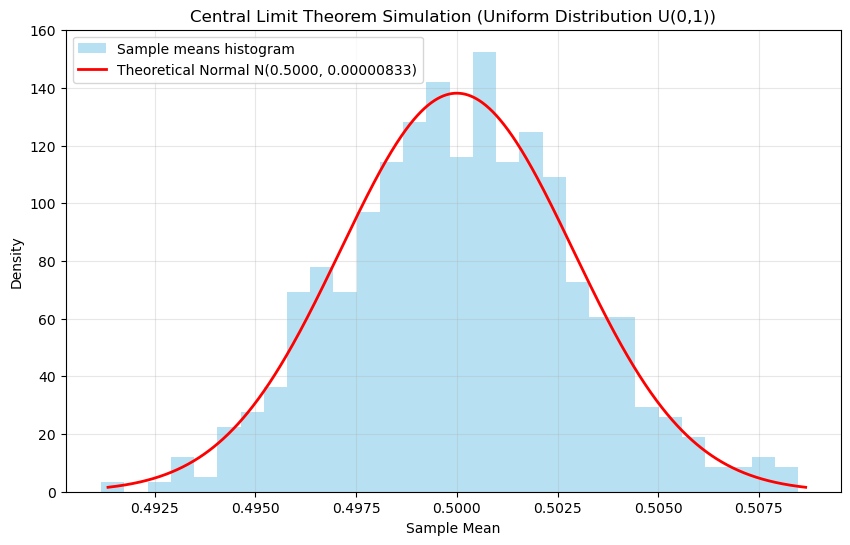

理论方差: 0.00000833
实际方差: 0.00000847


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------- 1. 模拟均值 ----------------------
n = 10000  # 每次样本数量
m = 1000   # 重复次数

# 生成 m 次均值
means = []
for _ in range(m):
    # 生成 n 个 U(0,1) 的随机变量
    samples = np.random.uniform(low=0, high=1, size=n)
    # 计算均值
    mean_val = np.mean(samples)
    means.append(mean_val)

means = np.array(means)

# ---------------------- 2. 绘制直方图 + 理论正态曲线 ----------------------
# 均匀分布 U(0,1) 的理论参数
mu_uniform = 0.5
var_uniform = 1 / 12
sigma_uniform = np.sqrt(var_uniform)

# 均值的理论分布：N(mu, sigma^2/n)
mu_theory = mu_uniform
var_theory = var_uniform / n
sigma_theory = np.sqrt(var_theory)

# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', label='Sample means histogram')

# 绘制理论正态分布曲线
x = np.linspace(mu_theory - 3*sigma_theory, mu_theory + 3*sigma_theory, 1000)
y = norm.pdf(x, loc=mu_theory, scale=sigma_theory)
plt.plot(x, y, 'r-', lw=2, label=f'Theoretical Normal N({mu_theory:.4f}, {sigma_theory**2:.8f})')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title('Central Limit Theorem Simulation (Uniform Distribution U(0,1))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------- 3. 计算均值的实际方差 ----------------------
actual_var = np.var(means, ddof=1)  # 无偏估计方差
print(f"理论方差: {var_theory:.8f}")
print(f"实际方差: {actual_var:.8f}")